**importing necessary models**

In [44]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [45]:
df = pd.read_csv('/kaggle/input/datasets/maratheabhishek/ipl-dataset-2008-to-2025/ball_by_ball_data.csv')
match = pd.read_csv('/kaggle/input/datasets/maratheabhishek/ipl-dataset-2008-to-2025/ipl_matches_data.csv')

In [46]:
df = df[df['match_id']>1304046]

In [47]:
win = match[['match_id','match_winner']]
df = df.merge(win, how = 'inner',on=['match_id'])

In [48]:
df['succ_chase'] = (df['team_batting'] == df['match_winner']).astype(int)

In [49]:
df = df.drop(columns=['is_super_over','penalty_runs','bye_runs','leg_bye_runs','no_ball_runs','wide_ball_runs','is_penalty','is_bye','is_leg_bye','is_no_ball','is_wide_ball','fielders_involved','player_out','bowler_type','batsman_type','batter','bowler','non_striker'])

In [50]:
df['curr_run'] = df.groupby(['match_id','innings'])['total_runs'].cumsum()
df['curr_wick'] = df.groupby(['match_id','innings'])['is_wicket'].cumsum()
df['curr_ball'] = (df['over_number']*6) +(df['ball_number'])

In [51]:
tar = df[df['innings']==1]
tar = tar.groupby(['match_id'])['total_runs'].sum().reset_index(name='Total')
tar['target'] = tar['Total'] + 1
tar = tar[['match_id','target']]

In [52]:
df = df.merge(tar,left_on='match_id',right_on='match_id',how='left')

In [53]:
df = df[df['innings']==2]

In [54]:
df['cr'] = df['curr_run']*6/ df['curr_ball']
df['cr'] = df['cr'].replace(float('inf'),0)

In [55]:
df['req_runs'] = df['target'] - df['curr_run']
df['balls_left'] = 120 - df['curr_ball']
df['wick_left'] = 10 - df['curr_wick']


In [56]:
df['rr'] = df['req_runs'] * 6 / df['balls_left']
df['rr'] = df['rr'].replace([float('inf'),float('-inf')],0)

In [57]:
df = df[df['rr']>=0]
df = df[df['curr_wick']<10]
df = df[df['curr_ball']>10]
df = df[df['req_runs']>0]

In [58]:
df['rpw'] = df['curr_run'] / df['curr_wick']
df['rpw'] = df['rpw'].replace(float('inf'),0)
df['rrpw'] = df['req_runs']/ df['wick_left']
df.fillna(0)

,season_id,match_id,team_batting,team_bowling,over_number,ball_number,batter_runs,extras,total_runs,is_wicket,...,curr_wick,curr_ball,target,cr,req_runs,balls_left,wick_left,rr,rpw,rrpw
2,2022,1304047,6,129,1,5,0,0,0,False,...,0,11,132,0.000000,132,109,10,7.266055,0.000000,13.200000
138,2022,1304047,6,129,2,0,0,0,0,False,...,0,12,132,4.000000,124,108,10,6.888889,0.000000,12.400000
139,2022,1304047,6,129,2,1,0,0,0,False,...,0,13,132,3.692308,124,107,10,6.953271,0.000000,12.400000
140,2022,1304047,6,129,2,2,1,0,1,False,...,0,14,132,3.857143,123,106,10,6.962264,0.000000,12.300000
141,2022,1304047,6,129,2,3,2,0,2,False,...,0,15,132,4.400000,121,105,10,6.914286,0.000000,12.100000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80178,2026,1529286,252,134,18,2,0,0,0,False,...,3,110,226,11.727273,11,10,7,6.600000,71.666667,1.571429
80179,2026,1529286,252,134,18,3,1,0,1,False,...,3,111,226,11.675676,10,9,7,6.666667,72.000000,1.428571
80180,2026,1529286,252,134,18,4,1,0,1,False,...,3,112,226,11.625000,9,8,7,6.750000,72.333333,1.285714
80181,2026,1529286,252,134,18,5,4,0,4,False,...,3,113,226,11.734513,5,7,7,4.285714,73.666667,0.714286


In [59]:
X = df[[
        'team_batting',
        'team_bowling',
        'target',
        'curr_run',
        'curr_ball',
        'curr_wick',
        'cr',
        'rpw',
        'req_runs',
        'balls_left',
        'wick_left',
        'rr',
        'rrpw'
       ]]
y = df['succ_chase']

In [60]:
X = X.fillna(0)

In [61]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(test_size=0.2, random_state=42)

train_idx, test_idx = next(
    gss.split(X, y, groups=df["match_id"])
)

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

In [62]:
from sklearn.metrics import accuracy_score as ac
from sklearn.metrics import confusion_matrix as cm


In [63]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train,y_train)
y_lr = lr.predict(X_test)

In [64]:
cm(y_test,y_lr)

array([[3327,  351],
       [ 512, 2697]])

In [65]:
from sklearn.tree import DecisionTreeClassifier
dtc = DecisionTreeClassifier()
dtc.fit(X_train,y_train)
y_dtc = dtc.predict(X_test)

In [66]:
cm(y_test,y_dtc)

array([[2996,  682],
       [ 796, 2413]])

In [67]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier()
rfc.fit(X_train,y_train)
y_rfc = rfc.predict(X_test)

In [68]:
cm(y_test,y_rfc)

array([[3283,  395],
       [ 695, 2514]])

In [69]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=1000,
    max_depth=10,
    learning_rate=0.02,
    random_state=42
)

xgb.fit(X_train,y_train)
y_xg = xgb.predict(X_test)

In [70]:
cm(y_test,y_xg)

array([[3196,  482],
       [ 589, 2620]])

In [71]:
from sklearn.model_selection import cross_val_score

score = cross_val_score(xgb,X_test,y_test,cv=5,scoring='accuracy')
pd.DataFrame(score)

,0
0,0.706821
1,0.849057
2,0.697168
3,0.925200
4,0.823529


In [72]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix
print(' Accuracy  : ',accuracy_score(y_test,y_xg))
print(' Precision : ', precision_score(y_test,y_xg))
print(' Recall    : ',recall_score(y_test,y_xg))
print(' f1 score  : ',f1_score(y_test,y_xg))
print(' C matrix  : ', confusion_matrix(y_test,y_xg))


 Accuracy  :  0.8444896181210977
 Precision :  0.8446163765312702
 Recall    :  0.8164537239015269
 f1 score  :  0.8302963080335921
 C matrix  :  [[3196  482]
 [ 589 2620]]


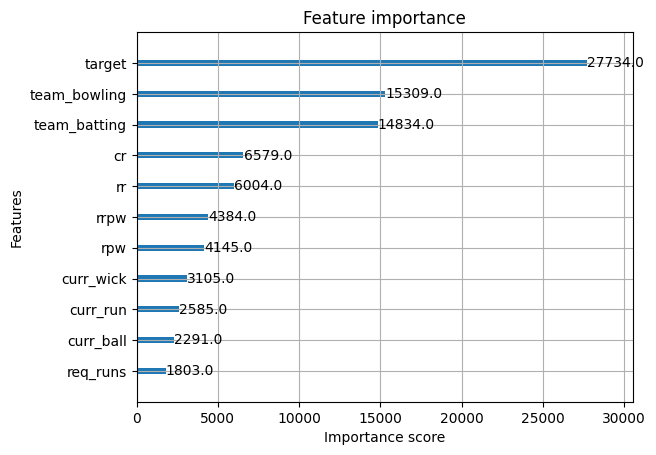

In [73]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

plot_importance(xgb)
plt.show()

In [74]:
import joblib
joblib.dump(xgb,'model.pkl')

['model.pkl']

In [75]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
pipe = Pipeline([('scaler',StandardScaler()),
               ('model',KNeighborsClassifier())])
pipe.fit(X_train,y_train)

k_pr = pipe.predict(X_test)

In [76]:
cm(y_test,k_pr)

array([[3161,  517],
       [ 926, 2283]])

In [82]:
df.groupby('team_batting')['total_runs'].sum().sort_values(ascending=False)

team_batting
3      6154
252    6030
615    6005
134    5538
494    5203
2      4757
614    4560
1      4436
6      4326
129    4018
Name: total_runs, dtype: int64

In [81]:
X.team_batting.value_counts()

team_batting
252    4184
615    4146
3      4055
134    3634
494    3375
614    3261
2      3220
6      2954
1      2858
129    2822
Name: count, dtype: int64